# Ensemble Model for PCOS Classification
This notebook develops an ensemble model integrating Random Forest (RF), Logistic Regression (LR), and K-Nearest Neighbors (KNN).

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from adapter import LocalDatasetAdapter

## Preprocessing

In [24]:
# Load and preprocess data
local_dataset = pd.read_csv("../data/local/cebu.csv")
adapter = LocalDatasetAdapter(local_dataset)
preprocessed_local_dataset = adapter.convert()

preprocessed_local_dataset.head()

/Users/nickanthonymiras/Programming/projects/pcos-analysis/notebooks/adapter.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_dataframe[features.infertility] = filtered_dataframe[features.infertility].apply(lambda x: 1 if x == 'G1P0' or x == 'G3P2' else 0)
/Users/nickanthonymiras/Programming/projects/pcos-analysis/notebooks/adapter.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_dataframe[features.menstrual_irregularity] = filtered_dataframe[features.menstrual_irregularity].apply(

,bmi,age,has_pcos,infertility,menstrual_irregularity,acne,hirsutism,irregular_masses
0,25.9645,34,1,0,1,0,1,1
1,22.2137,22,1,0,1,1,0,1
2,22.8928,19,1,0,0,1,0,1
3,22.8928,24,1,0,1,1,0,1
4,19.7777,25,1,0,0,0,0,1


In [25]:
# Define features and target variable
X = preprocessed_local_dataset.drop(columns=['has_pcos'])
y = preprocessed_local_dataset['has_pcos']

# 80-20 Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Hyper-Optimization
Each base model underwent hyperparameter tuning using Grid Search with 10-fold cross-validation, ensuring optimal parameter configurations.

### Random Forest

In [26]:

rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(rf, rf_params, cv=10, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print("Best RF Params:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_

Best RF Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


### Logistic Regression

In [27]:
lr_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])
lr_params = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__solver': ['liblinear', 'lbfgs']
}
lr_grid = GridSearchCV(lr_pipeline, lr_params, cv=10, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)
print("Best LR Params:", lr_grid.best_params_)
best_lr = lr_grid.best_estimator_


Best LR Params: {'lr__C': 10, 'lr__solver': 'liblinear'}


### KNN

In [28]:
knn_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier())
])
knn_params = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__metric': ['euclidean', 'manhattan'],
    'knn__weights': ['uniform', 'distance']
}
knn_grid = GridSearchCV(knn_pipeline, knn_params, cv=10, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)
print("Best KNN Params:", knn_grid.best_params_)
best_knn = knn_grid.best_estimator_

Best KNN Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'uniform'}


## Ensemble
Fitting and Results

In [29]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('lr', best_lr),
        ('knn', best_knn)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test)

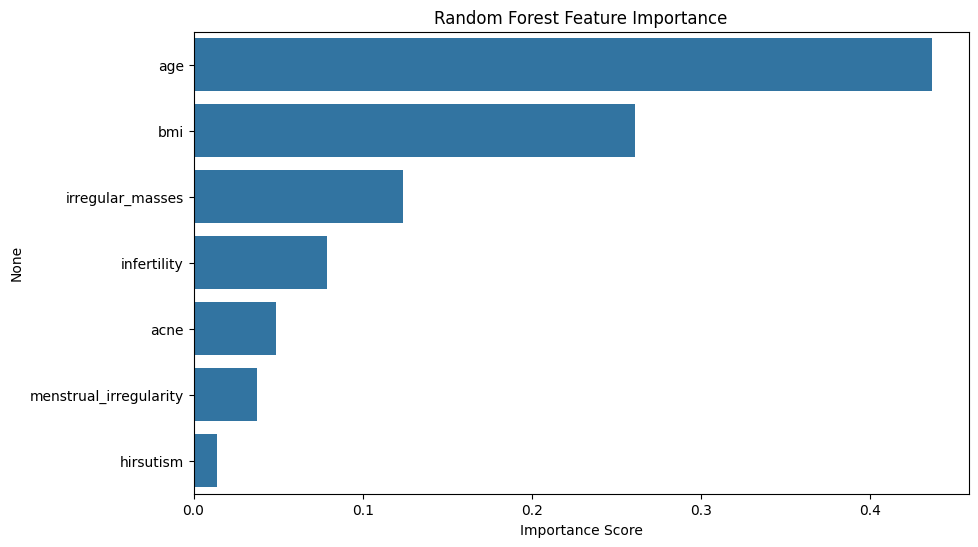

In [30]:
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

### LR Coefficient Interpretation

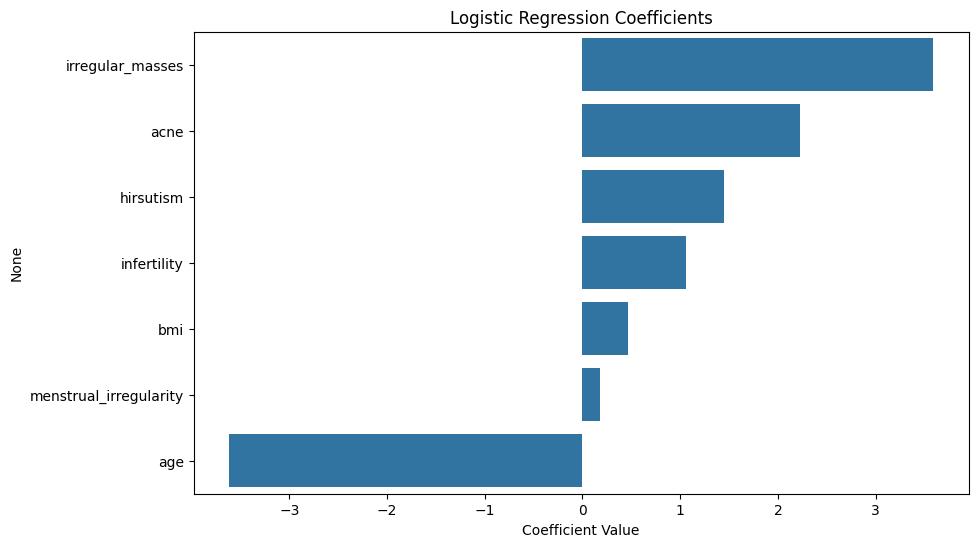

In [31]:
# Model Explainability: Coefficient Interpretation (Logistic Regression)
lr_model = best_lr.named_steps['lr']
coefficients = pd.Series(lr_model.coef_[0], index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients, y=coefficients.index)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.show()

### Shap Values

/Users/nickanthonymiras/miniconda3/envs/datascience/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/nickanthonymiras/miniconda3/envs/datascience/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/nickanthonymiras/miniconda3/envs/datascience/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
  0%|          | 0/20 [00:00<?, ?it/s]/Users/nickanthonymiras/miniconda3/envs/datascience/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/nickanthonymiras/mi

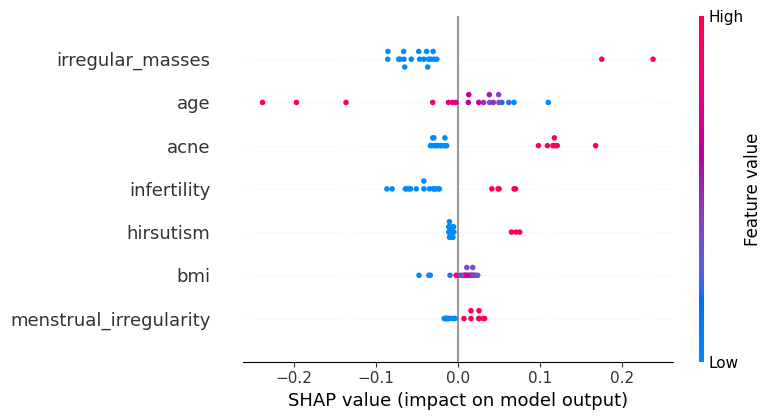

In [32]:
# Compute SHAP values using KernelExplainer for the ensemble model
# We use a summary of the training data as the background distribution to speed up computation
background_summary = shap.sample(X_train, 50)
explainer = shap.KernelExplainer(voting_clf.predict_proba, background_summary)

# Calculate SHAP values on a sample of the test set to reduce computation time
X_test_sample = shap.sample(X_test, 50)
shap_values = explainer.shap_values(X_test_sample)

# For a multi-class output (like predict_proba), KernelExplainer returns an array of shape (n_samples, n_features, n_classes)
# Or a list of arrays depending on the shap version. If it's an ndarray, we slice the last dimension.
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values[:, :, 1]

# Generate a summary plot for the positive class (class 1, predicting PCOS)
shap.summary_plot(shap_values_class1, X_test_sample)

## Metrics

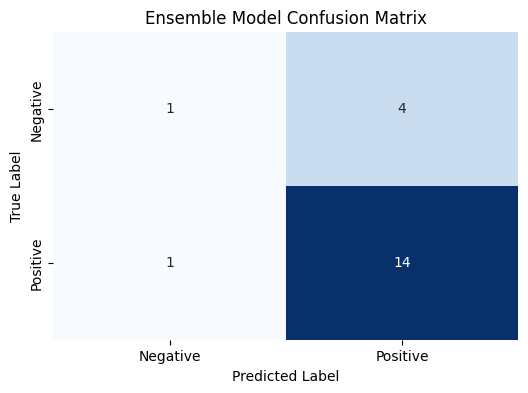

Ensemble Model Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.20      0.29         5
           1       0.78      0.93      0.85        15

    accuracy                           0.75        20
   macro avg       0.64      0.57      0.57        20
weighted avg       0.71      0.75      0.71        20

ROC-AUC Score: 0.7067


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Prettify Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Ensemble Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print("Ensemble Model Classification Report:\n")
print(classification_report(y_test, y_pred))

# ROC-AUC Score
y_pred_proba = voting_clf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

##### With K-fold Cross Validation (5 Folds)

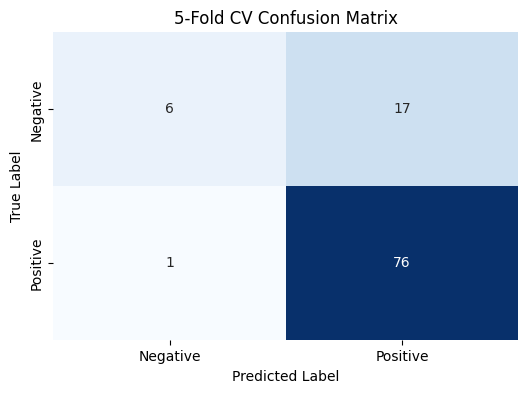

5-Fold CV Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.26      0.40        23
           1       0.82      0.99      0.89        77

    accuracy                           0.82       100
   macro avg       0.84      0.62      0.65       100
weighted avg       0.83      0.82      0.78       100

5-Fold CV ROC-AUC Score: 0.7758


In [34]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold

# 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get cross-validated predictions and probabilities
cv_y_pred = cross_val_predict(voting_clf, X, y, cv=cv)
cv_y_pred_proba = cross_val_predict(voting_clf, X, y, cv=cv, method='predict_proba')[:, 1]

# Prettify Confusion Matrix
cv_cm = confusion_matrix(y, cv_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cv_cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("5-Fold CV Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print("5-Fold CV Classification Report:\n")
print(classification_report(y, cv_y_pred))

# ROC-AUC Score
cv_roc_auc = roc_auc_score(y, cv_y_pred_proba)
print(f"5-Fold CV ROC-AUC Score: {cv_roc_auc:.4f}")

# Conclusion